In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

from sklearn.metrics import mean_squared_error
from math import sqrt

import joblib
import warnings
warnings.filterwarnings("ignore")

In [32]:
df=pd.read_csv('RELIANCE.NS.csv')

In [33]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2000-01-03,33.917892,35.945827,33.917892,35.945827,26.684866,31204789.0
1,2000-01-04,36.902668,38.823490,35.888702,38.823490,28.821142,66436055.0
2,2000-01-05,36.652744,41.115627,36.652744,40.344440,29.950235,187894923.0
3,2000-01-06,41.272720,42.943623,41.272720,42.036766,31.206556,109810562.0
4,2000-01-07,42.129593,45.399994,41.843967,44.921570,33.348133,139140630.0


In [34]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
6074,2024-04-23,2958.000000,2987.000000,2911.100098,2918.649902,2918.649902,7302777.0
6075,2024-04-24,2927.000000,2937.100098,2899.000000,2900.350098,2900.350098,5231388.0
6076,2024-04-25,2885.000000,2935.949951,2883.000000,2919.949951,2919.949951,7971963.0
6077,2024-04-26,2927.899902,2930.000000,2900.000000,2905.100098,2905.100098,4706924.0
6078,2024-04-29,2900.000000,2935.800049,2900.000000,2930.050049,2930.050049,3623987.0


In [35]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,6069.000000,6069.000000,6069.000000,6069.000000,6069.000000,6.069000e+03
mean,689.282224,697.132526,680.887468,688.717071,665.596257,1.759492e+07
std,744.042341,751.140627,736.631838,743.652502,746.829061,1.927247e+07
min,29.347902,31.347273,28.155420,29.019436,21.542969,0.000000e+00
25%,114.392555,116.963173,113.971260,115.435089,100.121124,6.592663e+06
50%,431.793610,437.051025,425.621887,431.610748,396.301300,1.052491e+07
75%,852.798096,861.164246,843.151917,851.518066,828.857910,2.120097e+07
max,3011.550049,3024.899902,2974.449951,3014.800049,3014.800049,3.161448e+08


In [36]:
df.shape

(6079, 7)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6079 entries, 0 to 6078
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6079 non-null   object 
 1   Open       6069 non-null   float64
 2   High       6069 non-null   float64
 3   Low        6069 non-null   float64
 4   Close      6069 non-null   float64
 5   Adj Close  6069 non-null   float64
 6   Volume     6069 non-null   float64
dtypes: float64(6), object(1)
memory usage: 332.6+ KB


In [38]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [39]:
df.isnull().sum()

Open         10
High         10
Low          10
Close        10
Adj Close    10
Volume       10
dtype: int64

In [40]:
df.dropna(inplace=True)

In [41]:
df.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

#### short-term and long-term trend analysis

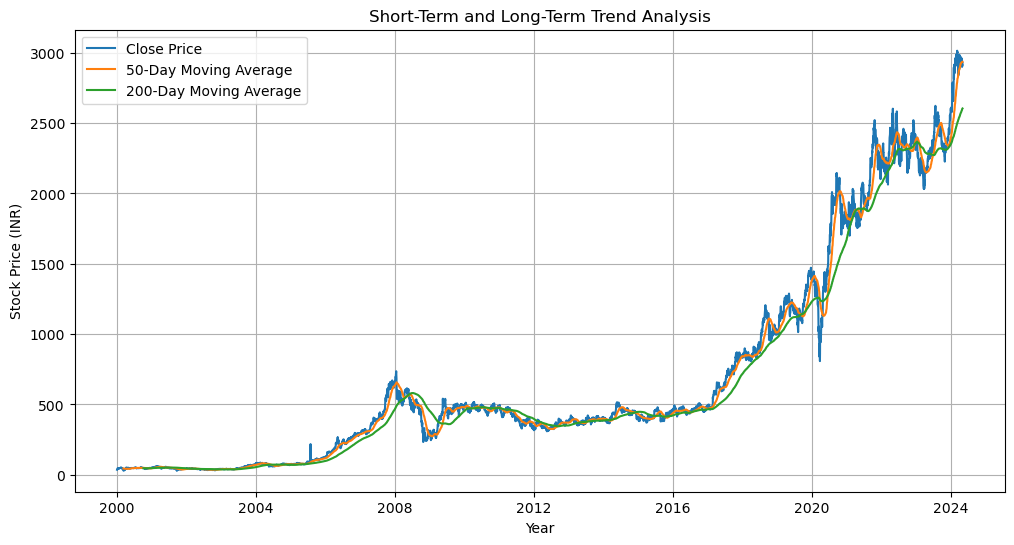

In [42]:
df['MA_50'] = df['Close'].rolling(50).mean()
df['MA_200'] = df['Close'].rolling(200).mean()

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label="Close Price")
plt.plot(df.index, df['MA_50'], label="50-Day Moving Average")
plt.plot(df.index, df['MA_200'], label="200-Day Moving Average")

plt.title("Short-Term and Long-Term Trend Analysis")
plt.xlabel("Year")
plt.ylabel("Stock Price (INR)")
plt.legend()
plt.grid(True)
plt.show()

#### Volality

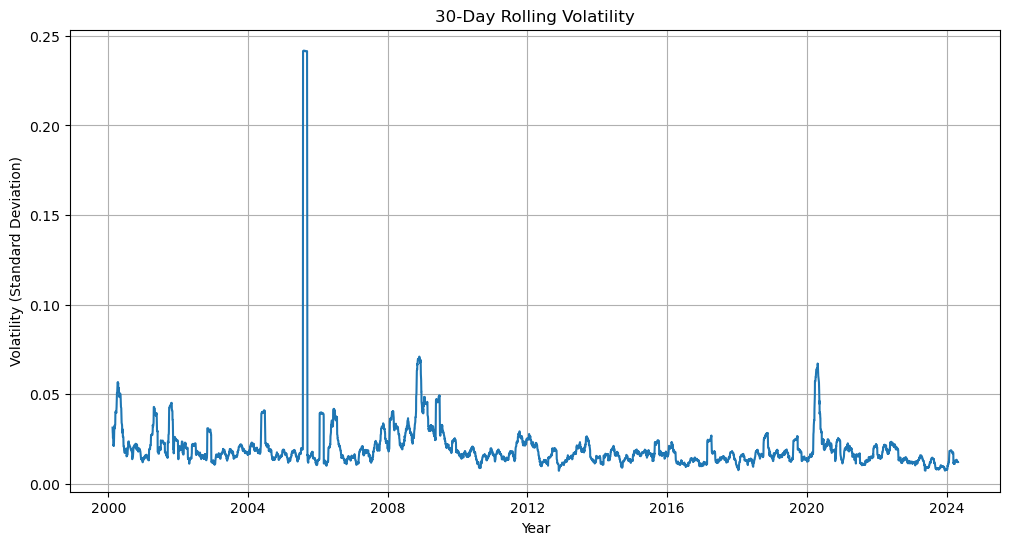

In [43]:
df['Daily_Return'] = df['Close'].pct_change()
df['Volatility'] = df['Daily_Return'].rolling(30).std()

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Volatility'])

plt.title("30-Day Rolling Volatility")
plt.xlabel("Year")
plt.ylabel("Volatility (Standard Deviation)")
plt.grid(True)
plt.show()

#### external events

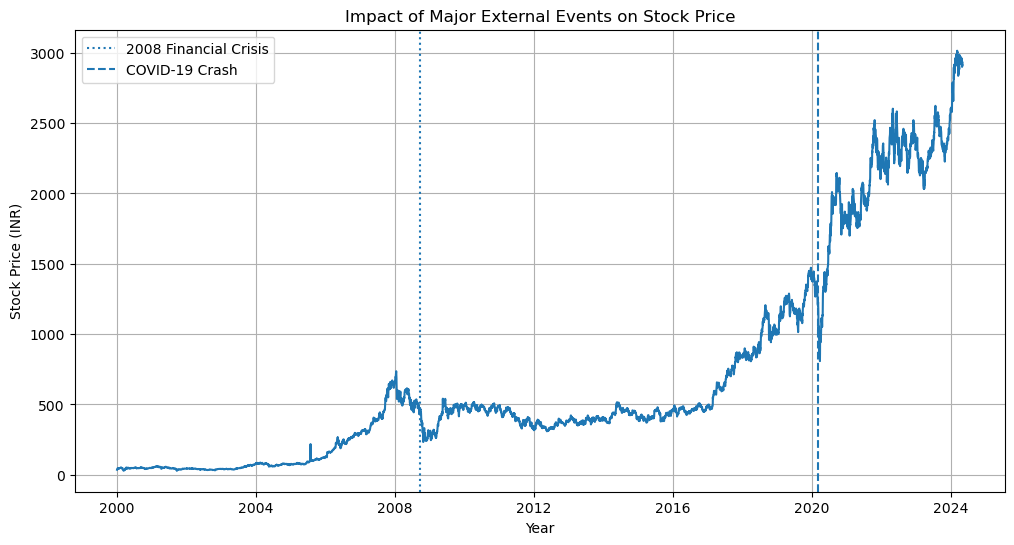

In [44]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'])

plt.axvline(pd.to_datetime("2008-09-15"), linestyle=':', label="2008 Financial Crisis")
plt.axvline(pd.to_datetime("2020-03-01"), linestyle='--', label="COVID-19 Crash")

plt.title("Impact of Major External Events on Stock Price")
plt.xlabel("Year")
plt.ylabel("Stock Price (INR)")
plt.legend()
plt.grid(True)
plt.show()

#### correlation

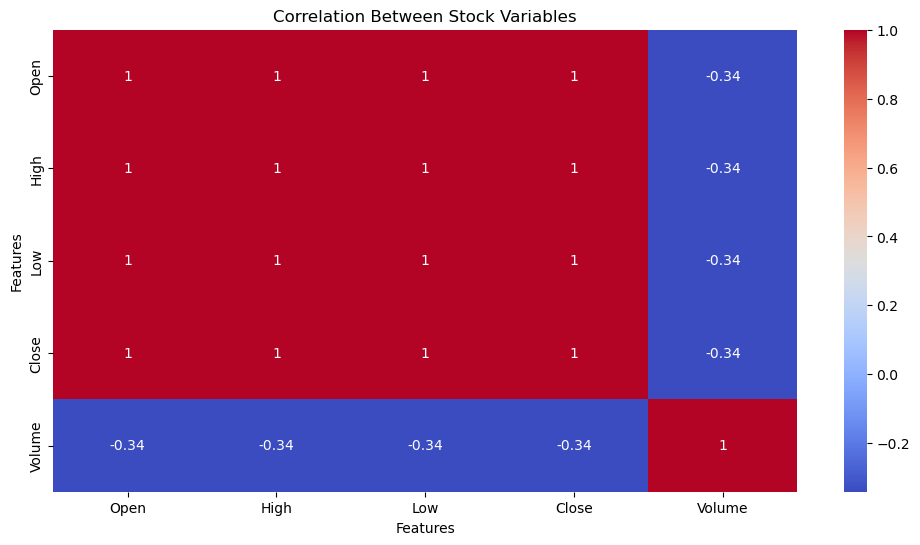

In [45]:
plt.figure(figsize=(12,6))
sn.heatmap(df[['Open','High','Low','Close','Volume']].corr(), 
            annot=True, cmap="coolwarm")

plt.title("Correlation Between Stock Variables")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()

#### Stationary Checking

In [46]:
adf_result = adfuller(df['Close'])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] > 0.05:
    print("Data is NOT stationary → Applying 1st order differencing")
    df_diff = df['Close'].diff().dropna()
else:
    print("Data is Stationary")

ADF Statistic: 1.5204881292712507
p-value: 0.9975982951420401
Data is NOT stationary → Applying 1st order differencing


#### ACF and PACF

<Figure size 1200x500 with 0 Axes>

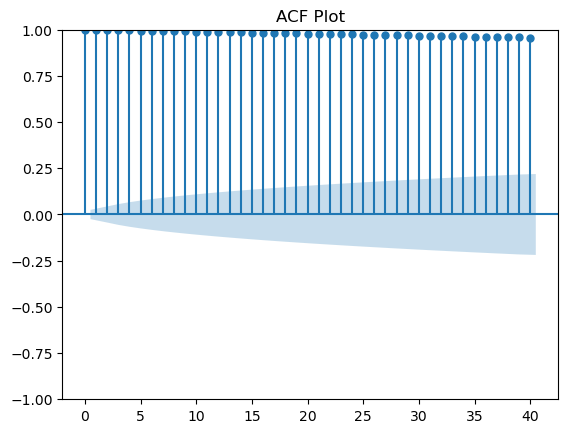

<Figure size 1200x500 with 0 Axes>

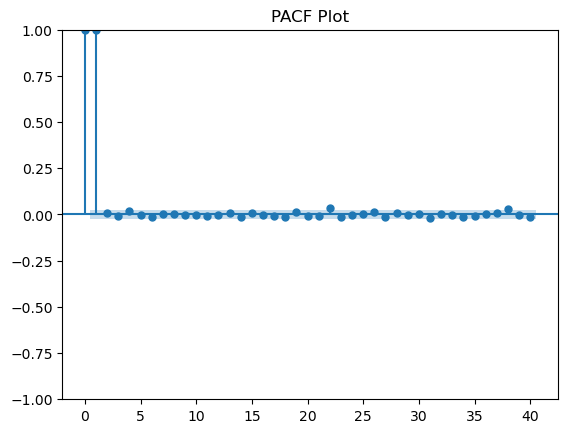

In [47]:
plt.figure(figsize=(12,5))
plot_acf(df['Close'], lags=40)
plt.title("ACF Plot")
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(df['Close'], lags=40)
plt.title("PACF Plot")
plt.show()

#### train test split

In [48]:
train = df[df.index < "2023-01-01"]
test = df[df.index >= "2023-01-01"]

print("Train Size:", train.shape)
print("Test Size:", test.shape)

Train Size: (5745, 10)
Test Size: (324, 10)


# Model Building

##### Arima

In [49]:
arima_model = ARIMA(train['Close'], order=(5,1,0))
arima_result = arima_model.fit()

arima_pred = arima_result.forecast(steps=len(test))
rmse_arima = sqrt(mean_squared_error(test['Close'], arima_pred))
print("ARIMA RMSE:", rmse_arima)

ARIMA RMSE: 287.8742302405084


##### sarima

In [50]:
sarima_model = SARIMAX(
    train['Close'],
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

sarima_pred = sarima_result.forecast(steps=len(test))
rmse_sarima = sqrt(mean_squared_error(test['Close'], sarima_pred))
print("SARIMA RMSE:", rmse_sarima)

SARIMA RMSE: 227.24046251555185


##### prophet

In [51]:
prophet_train = train[['Close']].reset_index()
prophet_train = prophet_train.rename(columns={'Date':'ds','Close':'y'})

prophet_model = Prophet()
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=len(test))
forecast = prophet_model.predict(future)

prophet_pred = forecast['yhat'].iloc[-len(test):].values
rmse_prophet = sqrt(mean_squared_error(test['Close'], prophet_pred))

print("Prophet RMSE:", rmse_prophet)

12:06:28 - cmdstanpy - INFO - Chain [1] start processing
12:06:32 - cmdstanpy - INFO - Chain [1] done processing


Prophet RMSE: 291.6826660671699


### model comparision

In [52]:
results = pd.DataFrame({
    'Model': ['ARIMA','SARIMA','Prophet'],
    'RMSE': [rmse_arima, rmse_sarima, rmse_prophet]
})

results = results.sort_values(by='RMSE')
print("\nModel Comparison:")
print(results)

best_model = results.iloc[0]['Model']
print("\nBest Model Selected:", best_model)


Model Comparison:
     Model        RMSE
1   SARIMA  227.240463
0    ARIMA  287.874230
2  Prophet  291.682666

Best Model Selected: SARIMA


In [53]:
if best_model == "ARIMA":
    final_model = ARIMA(df['Close'], order=(5,1,0)).fit()

elif best_model == "SARIMA":
    final_model = SARIMAX(
        df['Close'],
        order=(1,1,1),
        seasonal_order=(1,1,1,7),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit()

elif best_model == "Prophet":
    prophet_full = df[['Close']].reset_index()
    prophet_full = prophet_full.rename(columns={'Date':'ds','Close':'y'})
    final_model = Prophet().fit(prophet_full)

#### Retrain model on full dataset

In [54]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

final_model = SARIMAX(
    df['Close'],
    order=(1,1,1),                 # use your best parameters
    seasonal_order=(1,1,1,7),      # use your best parameters
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_result = final_model.fit()

print("Final SARIMA model trained on full dataset")

Final SARIMA model trained on full dataset


#### Forecast Next 1 Year (252 Trading Days)

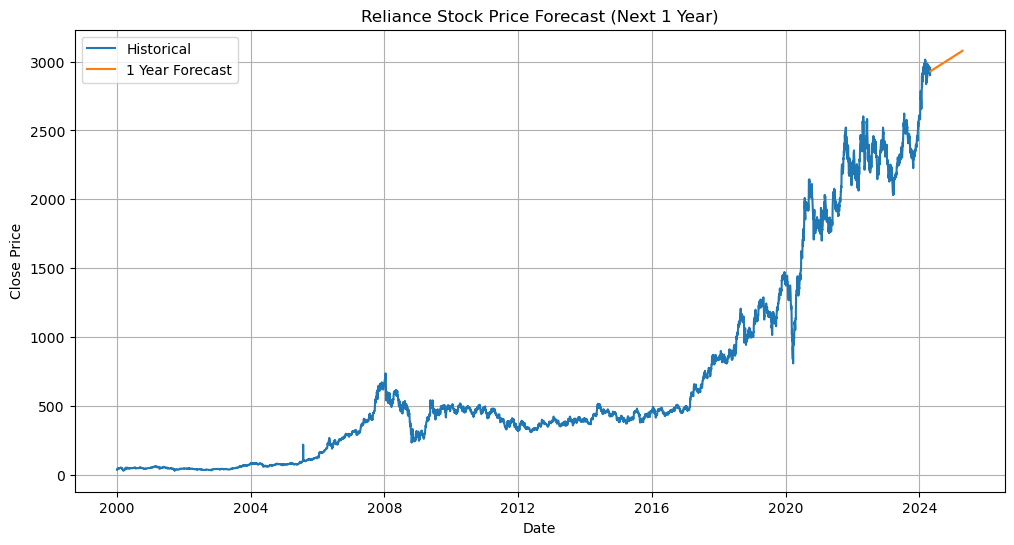

In [55]:
future_steps = 252   # 1 trading year
future_forecast = final_result.forecast(steps=future_steps)
future_dates = pd.date_range(
    start=df.index[-1],
    periods=future_steps+1,
    freq='B'
)[1:]
future_forecast.index = future_dates

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label="Historical")
plt.plot(future_forecast, label="1 Year Forecast")
plt.title("Reliance Stock Price Forecast (Next 1 Year)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

#### Save final model

In [56]:
import joblib

joblib.dump(final_result, "sarima_model.joblib", compress=3)

print("Model saved successfully")

Model saved successfully
